# Task 2 — Exploratory Data Analysis
### Ethiopia Financial Inclusion Forecasting — Selam Analytics

**Objective:** Analyze patterns and factors influencing financial inclusion in Ethiopia using the
enriched dataset from Task 1 (77 records).

**Sections**
1. Dataset overview
2. Access analysis (trajectory, growth rates, gender gap, the 2021-2024 slowdown)
3. Usage analysis (digital payments, registered vs. active gap, payment mix)
4. Infrastructure & enablers
5. Event timeline & visual overlay
6. Correlation analysis
7. Key insights
8. Data quality assessment


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 150

FIG_DIR = '../reports/figures'
import os
os.makedirs(FIG_DIR, exist_ok=True)


In [2]:
df = pd.read_csv('../data/processed/ethiopia_fi_unified_data_enriched.csv')
df['observation_date'] = pd.to_datetime(df['observation_date'], errors='coerce')

obs = df[df['record_type'] == 'observation'].copy()
events = df[df['record_type'] == 'event'].copy()
targets = df[df['record_type'] == 'target'].copy()
impact_links = df[df['record_type'] == 'impact_link'].copy()

print(f"Observations: {len(obs)} | Events: {len(events)} | Targets: {len(targets)} | Impact links: {len(impact_links)}")


Observations: 42 | Events: 13 | Targets: 3 | Impact links: 19


## 1. Dataset Overview

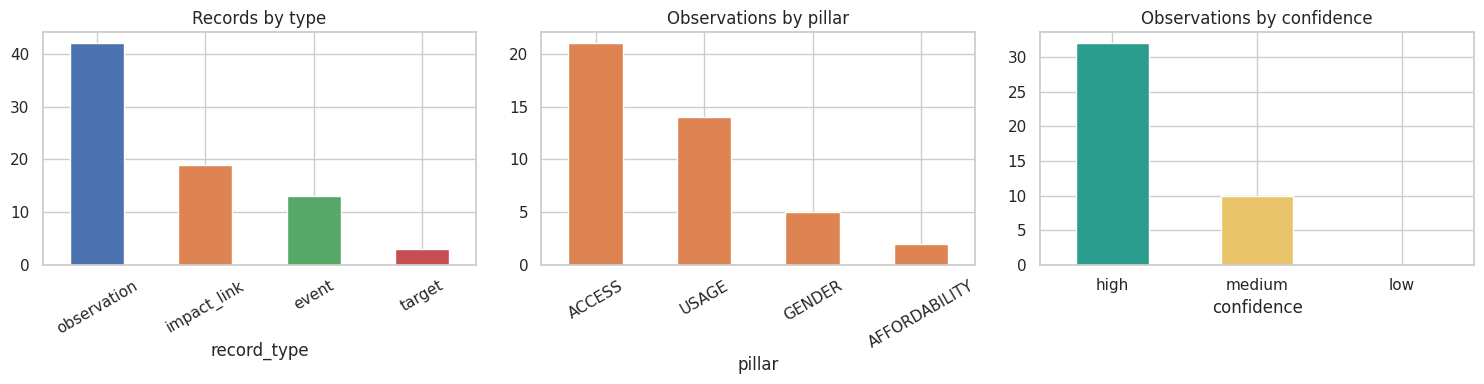

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df['record_type'].value_counts().plot(kind='bar', ax=axes[0], color=sns.color_palette('deep'))
axes[0].set_title('Records by type')
axes[0].tick_params(axis='x', rotation=30)

obs['pillar'].value_counts().plot(kind='bar', ax=axes[1], color=sns.color_palette('deep')[1])
axes[1].set_title('Observations by pillar')
axes[1].tick_params(axis='x', rotation=30)

obs['confidence'].value_counts().reindex(['high', 'medium', 'low']).plot(
    kind='bar', ax=axes[2], color=['#2a9d8f', '#e9c46a', '#e76f51'])
axes[2].set_title('Observations by confidence')
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/01_dataset_overview.png')
plt.show()


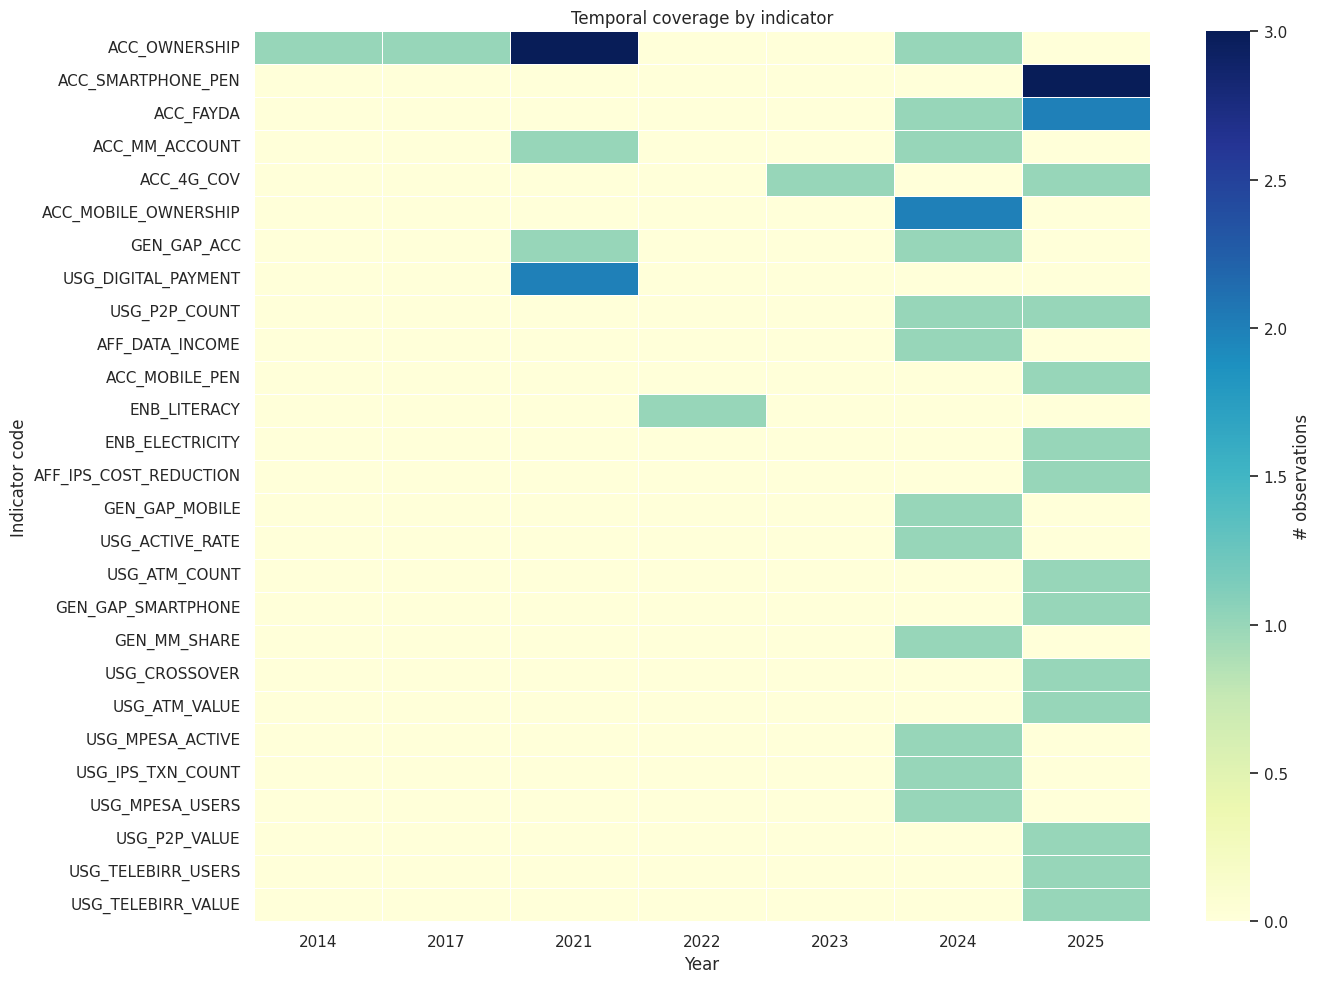

In [4]:
# Temporal coverage matrix: which indicators have data in which years
obs['year'] = obs['observation_date'].dt.year
coverage = obs.pivot_table(index='indicator_code', columns='year', values='record_id', aggfunc='count', fill_value=0)
coverage = coverage.reindex(coverage.sum(axis=1).sort_values(ascending=False).index)

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(coverage, cmap='YlGnBu', linewidths=0.5, linecolor='white', cbar_kws={'label': '# observations'}, ax=ax)
ax.set_title('Temporal coverage by indicator')
ax.set_xlabel('Year')
ax.set_ylabel('Indicator code')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/02_temporal_coverage.png')
plt.show()


In [5]:
# Data gaps: indicators with only 1 observation (no trend possible)
single_obs = coverage[coverage.sum(axis=1) == 1]
print(f"Indicators with only ONE observation (no trend derivable): {len(single_obs)}")
print(list(single_obs.index))


Indicators with only ONE observation (no trend derivable): 18
['AFF_DATA_INCOME', 'ACC_MOBILE_PEN', 'ENB_LITERACY', 'ENB_ELECTRICITY', 'AFF_IPS_COST_REDUCTION', 'GEN_GAP_MOBILE', 'USG_ACTIVE_RATE', 'USG_ATM_COUNT', 'GEN_GAP_SMARTPHONE', 'GEN_MM_SHARE', 'USG_CROSSOVER', 'USG_ATM_VALUE', 'USG_MPESA_ACTIVE', 'USG_IPS_TXN_COUNT', 'USG_MPESA_USERS', 'USG_P2P_VALUE', 'USG_TELEBIRR_USERS', 'USG_TELEBIRR_VALUE']


**Observation:** most indicators have only 1-3 observations — this is a fundamentally sparse
dataset. Only `ACC_OWNERSHIP`, `ACC_FAYDA`, `ACC_MM_ACCOUNT`, `ACC_4G_COV`, `USG_P2P_COUNT`, and
`GEN_GAP_ACC` have enough points to describe any trend at all.

## 2. Access Analysis

### 2.1 Account ownership trajectory (2011-2024)

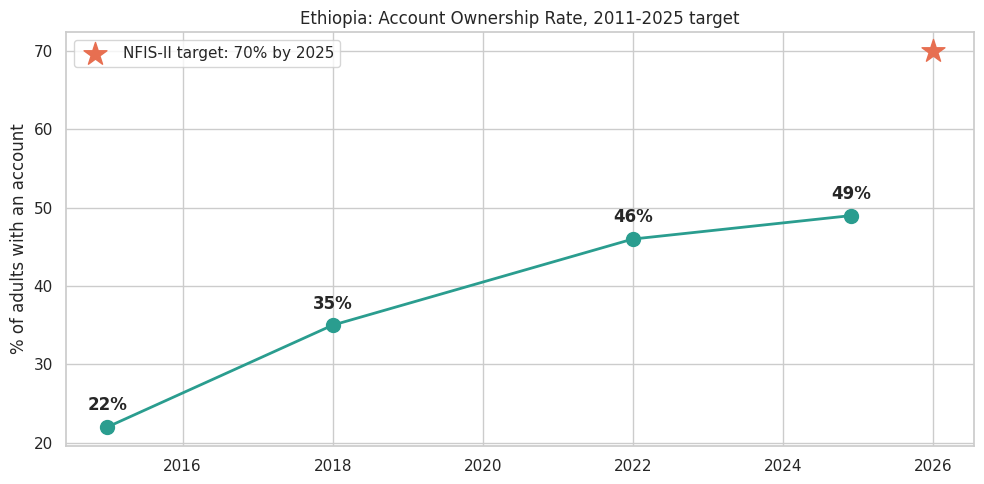

In [6]:
acc = obs[(obs['indicator_code'] == 'ACC_OWNERSHIP') & (obs['gender'] == 'all')].sort_values('observation_date')

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(acc['observation_date'], acc['value_numeric'], marker='o', markersize=10, linewidth=2, color='#2a9d8f')
for _, row in acc.iterrows():
    ax.annotate(f"{row['value_numeric']:.0f}%", (row['observation_date'], row['value_numeric']),
                textcoords='offset points', xytext=(0, 12), ha='center', fontweight='bold')

# NFIS-II target
tgt_acc = targets[targets['indicator_code'] == 'ACC_OWNERSHIP'].iloc[0]
ax.scatter([pd.to_datetime(tgt_acc['observation_date'])], [tgt_acc['value_numeric']],
           color='#e76f51', marker='*', s=300, zorder=5, label=f"NFIS-II target: {tgt_acc['value_numeric']:.0f}% by {pd.to_datetime(tgt_acc['observation_date']).year}")

ax.set_title("Ethiopia: Account Ownership Rate, 2011-2025 target")
ax.set_ylabel('% of adults with an account')
ax.legend()
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/03_account_ownership_trajectory.png')
plt.show()


In [7]:
acc = acc.reset_index(drop=True)
acc['years_elapsed'] = acc['observation_date'].dt.year.diff()
acc['pp_change'] = acc['value_numeric'].diff()
acc['pp_per_year'] = acc['pp_change'] / acc['years_elapsed']

print("Growth between Findex survey waves:")
acc[['observation_date', 'value_numeric', 'years_elapsed', 'pp_change', 'pp_per_year']]


Growth between Findex survey waves:


,observation_date,value_numeric,years_elapsed,pp_change,pp_per_year
0,2014-12-31,22.0,NaN,NaN,NaN
1,2017-12-31,35.0,3.0,13.0,4.333333
2,2021-12-31,46.0,4.0,11.0,2.750000
3,2024-11-29,49.0,3.0,3.0,1.000000


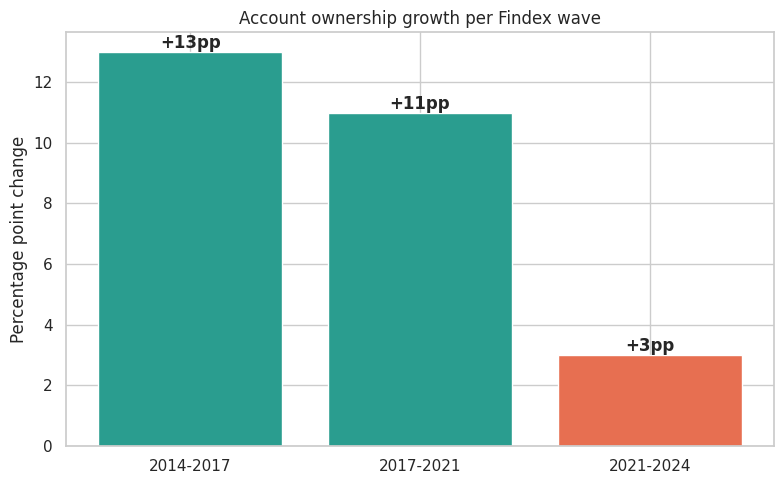

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
growth = acc.dropna(subset=['pp_change'])
labels = [f"{int(row['observation_date'].year)-int(row['years_elapsed'])}-{row['observation_date'].year}" for _, row in growth.iterrows()]
bars = ax.bar(labels, growth['pp_change'], color=['#2a9d8f', '#2a9d8f', '#e76f51'])
ax.set_ylabel('Percentage point change')
ax.set_title('Account ownership growth per Findex wave')
for bar, val in zip(bars, growth['pp_change']):
    ax.annotate(f'+{val:.0f}pp', (bar.get_x() + bar.get_width()/2, val), ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/04_growth_per_wave.png')
plt.show()


**The 2021-2024 slowdown is stark:** growth dropped from **+11pp** (2017-2021) to just **+3pp**
(2021-2024) — despite this being the exact window when Telebirr (May 2021), Safaricom (Aug 2022), and
M-Pesa (Aug 2023) all launched. The next cell investigates why, using the mobile-money-specific data.

In [9]:
mm = obs[obs['indicator_code'] == 'ACC_MM_ACCOUNT'].sort_values('observation_date')
print("Mobile money account ownership (subset of Access, Findex-defined):")
print(mm[['observation_date', 'value_numeric']].to_string(index=False))

mm_growth = mm['value_numeric'].iloc[-1] - mm['value_numeric'].iloc[0]
acc_growth = acc['value_numeric'].iloc[-1] - acc['value_numeric'].iloc[-2]
print(f"\nMobile money account ownership grew +{mm_growth:.1f}pp (2021-2024)")
print(f"But OVERALL account ownership only grew +{acc_growth:.0f}pp in the same window")
print(f"\nMeanwhile Telebirr alone reports {obs[obs['indicator_code']=='USG_TELEBIRR_USERS']['value_numeric'].iloc[0]/1e6:.1f}M registered users (mid-2025)")


Mobile money account ownership (subset of Access, Findex-defined):
observation_date  value_numeric
      2021-12-31           4.70
      2024-11-29           9.45

Mobile money account ownership grew +4.7pp (2021-2024)
But OVERALL account ownership only grew +3pp in the same window

Meanwhile Telebirr alone reports 54.8M registered users (mid-2025)


**Key finding — the "registered accounts vs. Findex-measured ownership" gap:** Telebirr alone
reports ~55M registered users, yet Findex-measured *mobile money account ownership* (a survey-based
measure of people who report actually using it in the past 12 months) sits at only 9.45% of adults
(~10-11M people) by end-2024. Millions of registrations are not converting into Findex-recognized,
active account ownership. Per the Market Nuances guide: **mobile-money-only users are rare (~0.5%)
in Ethiopia** — most mobile money activity sits on top of an existing bank account rather than
creating a *new* account holder, which is exactly why headline Findex "Account Ownership" barely
moved even as mobile money exploded. Registration is not usage, and usage is not new inclusion.

### 2.2 Gender gap in account ownership

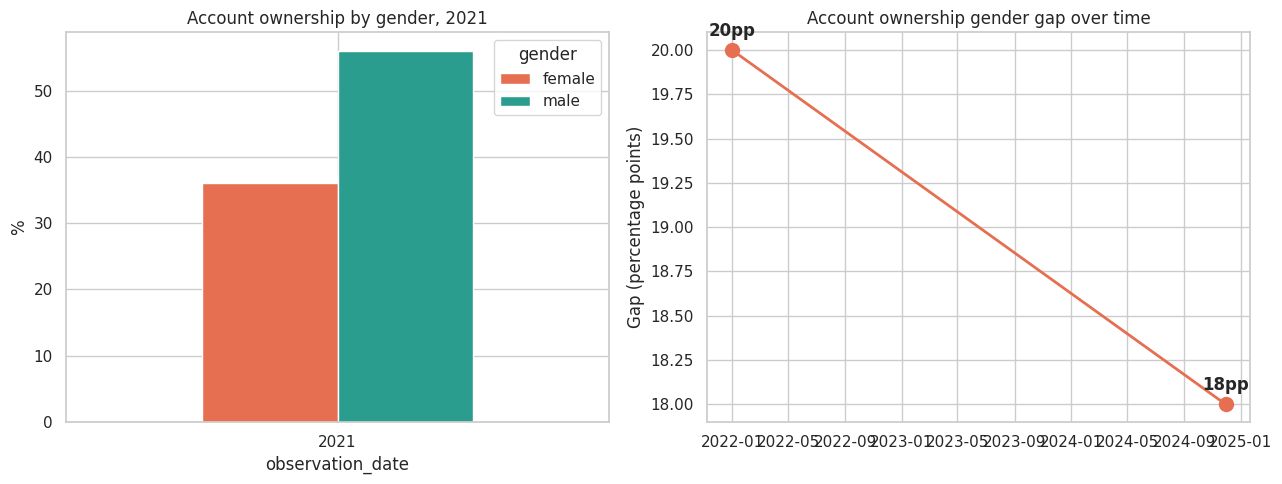

In [10]:
gender_acc = obs[(obs['indicator_code'] == 'ACC_OWNERSHIP') & (obs['gender'].isin(['male', 'female']))]
gap = obs[obs['indicator_code'] == 'GEN_GAP_ACC'].sort_values('observation_date')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

pivot = gender_acc.pivot_table(index='observation_date', columns='gender', values='value_numeric')
pivot.plot(kind='bar', ax=axes[0], color=['#e76f51', '#2a9d8f'])
axes[0].set_title('Account ownership by gender, 2021')
axes[0].set_ylabel('%')
axes[0].set_xticklabels([d.strftime('%Y') for d in pivot.index], rotation=0)

axes[1].plot(gap['observation_date'], gap['value_numeric'], marker='o', markersize=10, color='#e76f51', linewidth=2)
for _, row in gap.iterrows():
    axes[1].annotate(f"{row['value_numeric']:.0f}pp", (row['observation_date'], row['value_numeric']),
                      textcoords='offset points', xytext=(0, 10), ha='center', fontweight='bold')
axes[1].set_title('Account ownership gender gap over time')
axes[1].set_ylabel('Gap (percentage points)')

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/05_gender_gap_access.png')
plt.show()


Gender gap narrowed from 20pp (2021) to 18pp (2024) -- modest progress, not closing fast.

But the SMARTPHONE gender gap (43pp, 2025) is more than double the account-ownership gap.
This suggests device access -- not basic account access -- is now the wider gender fault line,
with implications for USAGE (not just ACCESS) going forward, since most digital financial
services increasingly assume smartphone-level access (QR codes, apps).


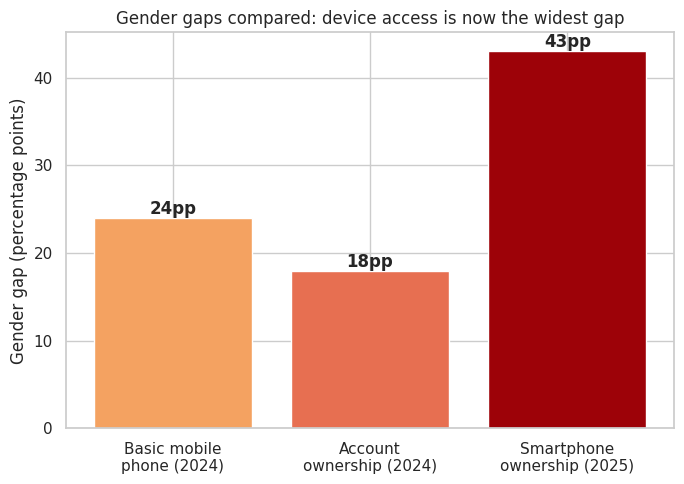

In [11]:
print("Gender gap narrowed from 20pp (2021) to 18pp (2024) -- modest progress, not closing fast.")
print()
print("But the SMARTPHONE gender gap (43pp, 2025) is more than double the account-ownership gap.")
print("This suggests device access -- not basic account access -- is now the wider gender fault line,")
print("with implications for USAGE (not just ACCESS) going forward, since most digital financial")
print("services increasingly assume smartphone-level access (QR codes, apps).")

fig, ax = plt.subplots(figsize=(7, 5))
gaps = pd.DataFrame({
    'gap_type': ['Basic mobile\nphone (2024)', 'Account\nownership (2024)', 'Smartphone\nownership (2025)'],
    'gap_pp': [24, 18, 43]
})
bars = ax.bar(gaps['gap_type'], gaps['gap_pp'], color=['#f4a261', '#e76f51', '#9d0208'])
ax.set_ylabel('Gender gap (percentage points)')
ax.set_title('Gender gaps compared: device access is now the widest gap')
for bar, val in zip(bars, gaps['gap_pp']):
    ax.annotate(f'{val}pp', (bar.get_x() + bar.get_width()/2, val), ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/06_gender_gaps_compared.png')
plt.show()


## 3. Usage (Digital Payments) Analysis

### 3.1 Mobile money penetration and P2P transaction growth

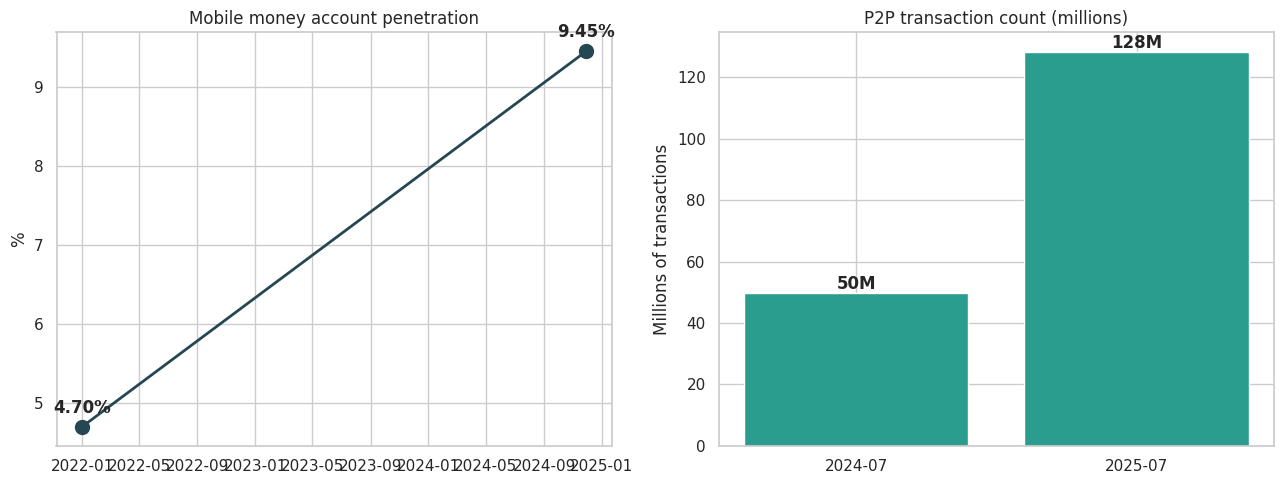

P2P transactions grew 158% in just 12 months (Jul 2024 to Jul 2025)


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

mm = obs[obs['indicator_code'] == 'ACC_MM_ACCOUNT'].sort_values('observation_date')
axes[0].plot(mm['observation_date'], mm['value_numeric'], marker='o', markersize=10, color='#264653', linewidth=2)
for _, row in mm.iterrows():
    axes[0].annotate(f"{row['value_numeric']:.2f}%", (row['observation_date'], row['value_numeric']),
                      textcoords='offset points', xytext=(0, 10), ha='center', fontweight='bold')
axes[0].set_title('Mobile money account penetration')
axes[0].set_ylabel('%')

p2p = obs[obs['indicator_code'] == 'USG_P2P_COUNT'].sort_values('observation_date')
axes[1].bar(p2p['observation_date'].dt.strftime('%Y-%m'), p2p['value_numeric'] / 1e6, color='#2a9d8f')
axes[1].set_title('P2P transaction count (millions)')
axes[1].set_ylabel('Millions of transactions')
for i, val in enumerate(p2p['value_numeric']):
    axes[1].annotate(f'{val/1e6:.0f}M', (i, val/1e6), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/07_usage_growth.png')
plt.show()

p2p_growth = (p2p['value_numeric'].iloc[-1] / p2p['value_numeric'].iloc[0] - 1) * 100
print(f"P2P transactions grew {p2p_growth:.0f}% in just 12 months (Jul 2024 to Jul 2025)")


### 3.2 Registered vs. active gap

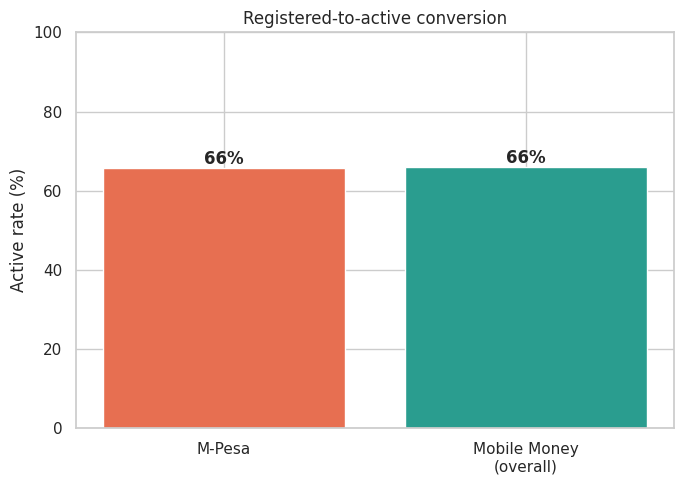

M-Pesa: 10.8M registered -> 7.1M active in 90 days = 65.7% active rate
Sector-wide mobile money activity rate (NBE-reported): 66% -- consistent cross-check.
=> roughly 1 in 3 registered mobile money accounts is NOT active. Registration counts
   dramatically overstate real usage, which is exactly why registered-user headlines
   (e.g. Telebirr's 55M) shouldn't be read as Findex-equivalent inclusion.


In [13]:
reg_active = pd.DataFrame({
    'provider': ['M-Pesa', 'Mobile Money\n(overall)'],
    'registered': [10_800_000, np.nan],
    'active_rate': [7_100_000 / 10_800_000 * 100, 66.0]
})

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(reg_active['provider'], reg_active['active_rate'], color=['#e76f51', '#2a9d8f'])
ax.set_ylabel('Active rate (%)')
ax.set_title('Registered-to-active conversion')
ax.set_ylim(0, 100)
for bar, val in zip(bars, reg_active['active_rate']):
    ax.annotate(f'{val:.0f}%', (bar.get_x() + bar.get_width()/2, val), ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/08_registered_vs_active.png')
plt.show()

print("M-Pesa: 10.8M registered -> 7.1M active in 90 days = 65.7% active rate")
print("Sector-wide mobile money activity rate (NBE-reported): 66% -- consistent cross-check.")
print("=> roughly 1 in 3 registered mobile money accounts is NOT active. Registration counts")
print("   dramatically overstate real usage, which is exactly why registered-user headlines")
print("   (e.g. Telebirr's 55M) shouldn't be read as Findex-equivalent inclusion.")


### 3.3 Digital payment usage by gender (2021 baseline) and use-case mix

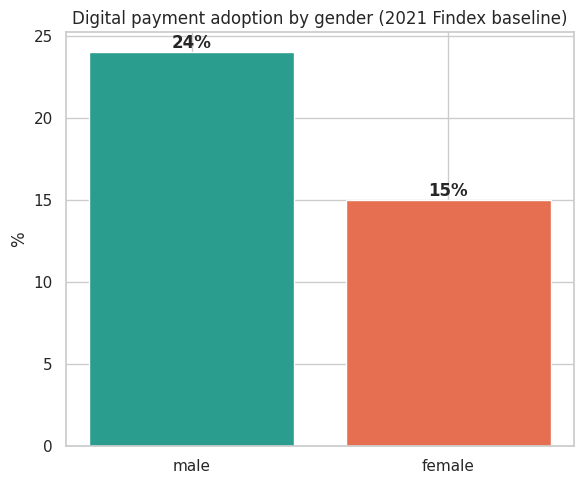

A 9pp usage gap existed in 2021 (24% male vs 15% female) -- narrower than the account-
ownership gap that same year (20pp), suggesting that once women have an account, the
usage gap is somewhat smaller than the access gap itself.


In [14]:
dp_gender = obs[obs['indicator_code'] == 'USG_DIGITAL_PAYMENT']
fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(dp_gender['gender'], dp_gender['value_numeric'], color=['#2a9d8f', '#e76f51'])
ax.set_ylabel('%')
ax.set_title('Digital payment adoption by gender (2021 Findex baseline)')
for bar, val in zip(bars, dp_gender['value_numeric']):
    ax.annotate(f'{val:.0f}%', (bar.get_x() + bar.get_width()/2, val), ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/09_digital_payment_gender.png')
plt.show()

print("A 9pp usage gap existed in 2021 (24% male vs 15% female) -- narrower than the account-")
print("ownership gap that same year (20pp), suggesting that once women have an account, the")
print("usage gap is somewhat smaller than the access gap itself.")


## 4. Infrastructure and Enablers

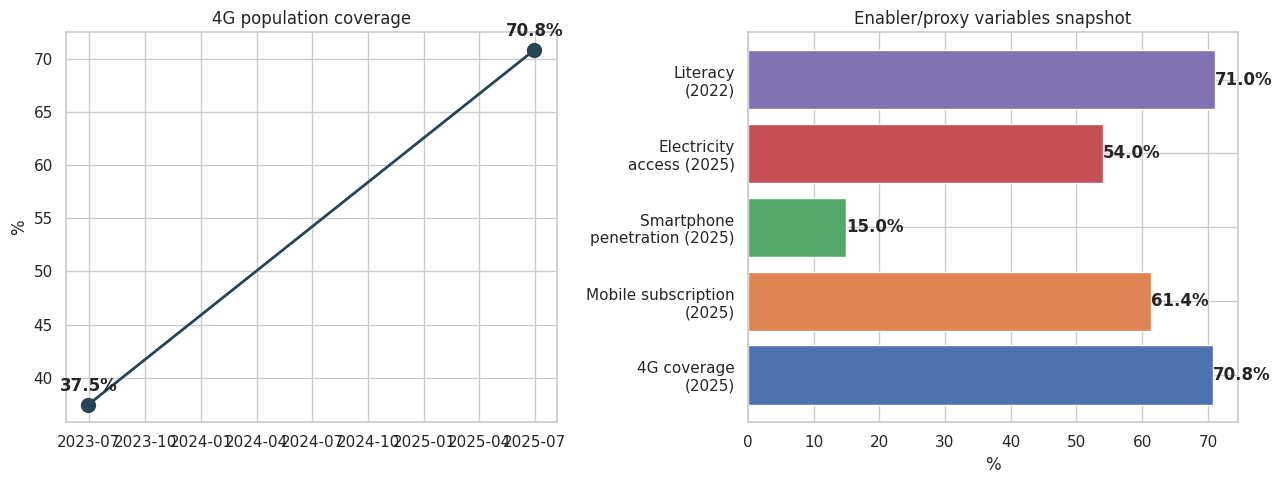

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

fourg = obs[obs['indicator_code'] == 'ACC_4G_COV'].sort_values('observation_date')
axes[0].plot(fourg['observation_date'], fourg['value_numeric'], marker='o', markersize=10, color='#264653', linewidth=2)
for _, row in fourg.iterrows():
    axes[0].annotate(f"{row['value_numeric']:.1f}%", (row['observation_date'], row['value_numeric']),
                      textcoords='offset points', xytext=(0, 10), ha='center', fontweight='bold')
axes[0].set_title('4G population coverage')
axes[0].set_ylabel('%')

enablers = pd.DataFrame({
    'enabler': ['4G coverage\n(2025)', 'Mobile subscription\n(2025)', 'Smartphone\npenetration (2025)', 'Electricity\naccess (2025)', 'Literacy\n(2022)'],
    'value': [70.8, 61.4, 15.0, 54.0, 71.04]
})
bars = axes[1].barh(enablers['enabler'], enablers['value'], color=sns.color_palette('deep'))
axes[1].set_xlabel('%')
axes[1].set_title('Enabler/proxy variables snapshot')
for bar, val in zip(bars, enablers['value']):
    axes[1].annotate(f'{val:.1f}%', (val, bar.get_y() + bar.get_height()/2), va='center', ha='left', fontweight='bold')

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/10_infrastructure_enablers.png')
plt.show()


**The infrastructure paradox:** 4G coverage reaches **70.8%** of the population and mobile
subscription penetration is **61.4%**, but only **15%** own a smartphone. Network coverage has
clearly outpaced device affordability. This is a strong candidate leading indicator: smartphone
penetration, not network coverage, is likely the binding constraint on further USAGE growth
(QR payments, apps, merchant acceptance), since basic mobile money (USSD-based, works on feature
phones) has already captured most of the "easy" USSD-capable population.

## 5. Event Timeline & Visual Overlay

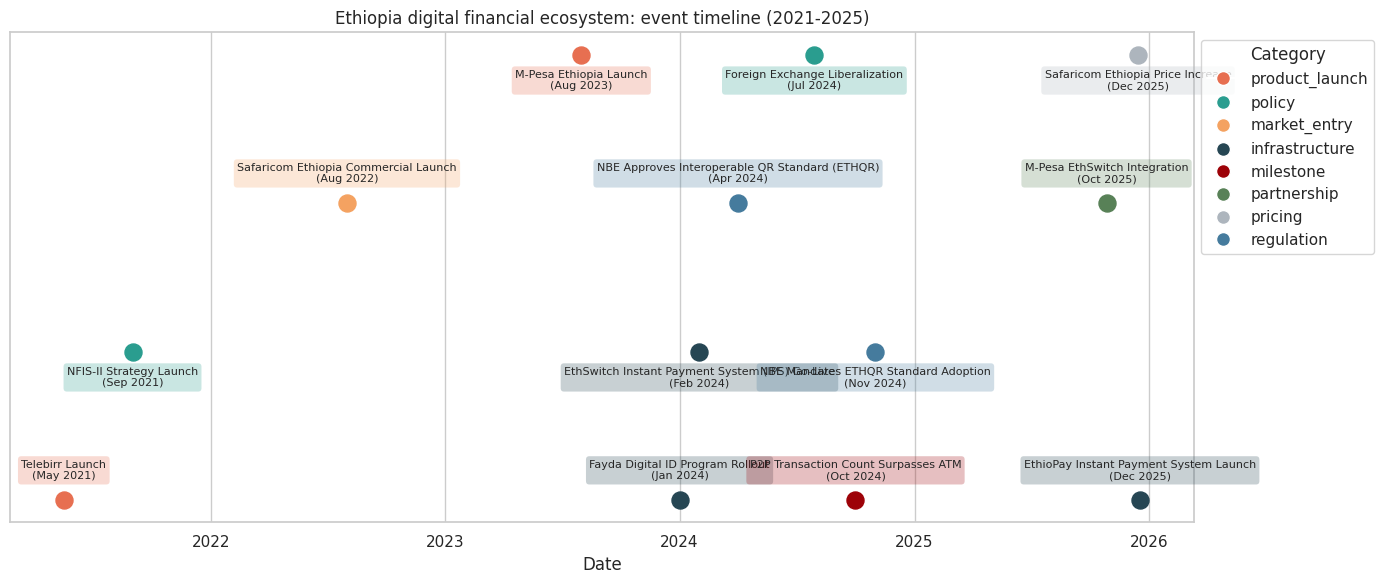

In [16]:
category_colors = {
    'product_launch': '#e76f51', 'policy': '#2a9d8f', 'market_entry': '#f4a261',
    'infrastructure': '#264653', 'milestone': '#9d0208', 'partnership': '#588157',
    'pricing': '#adb5bd', 'regulation': '#457b9d'
}

fig, ax = plt.subplots(figsize=(14, 6))
ev_sorted = events.sort_values('observation_date').reset_index(drop=True)
y_positions = np.arange(len(ev_sorted)) % 4  # stagger labels to avoid overlap

for i, row in ev_sorted.iterrows():
    color = category_colors.get(row['category'], 'gray')
    ax.scatter(row['observation_date'], y_positions[i], color=color, s=150, zorder=3)
    ax.annotate(f"{row['indicator']}\n({row['observation_date'].strftime('%b %Y')})",
                (row['observation_date'], y_positions[i]), textcoords='offset points',
                xytext=(0, 15 if y_positions[i] % 2 == 0 else -25), ha='center', fontsize=8,
                bbox=dict(boxstyle='round,pad=0.3', facecolor=color, alpha=0.25, edgecolor='none'))

ax.set_yticks([])
ax.set_title('Ethiopia digital financial ecosystem: event timeline (2021-2025)')
ax.set_xlabel('Date')
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=c, markersize=10, label=cat)
           for cat, c in category_colors.items() if cat in ev_sorted['category'].values]
ax.legend(handles=handles, loc='upper left', bbox_to_anchor=(1.0, 1.0), title='Category')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/11_event_timeline.png')
plt.show()


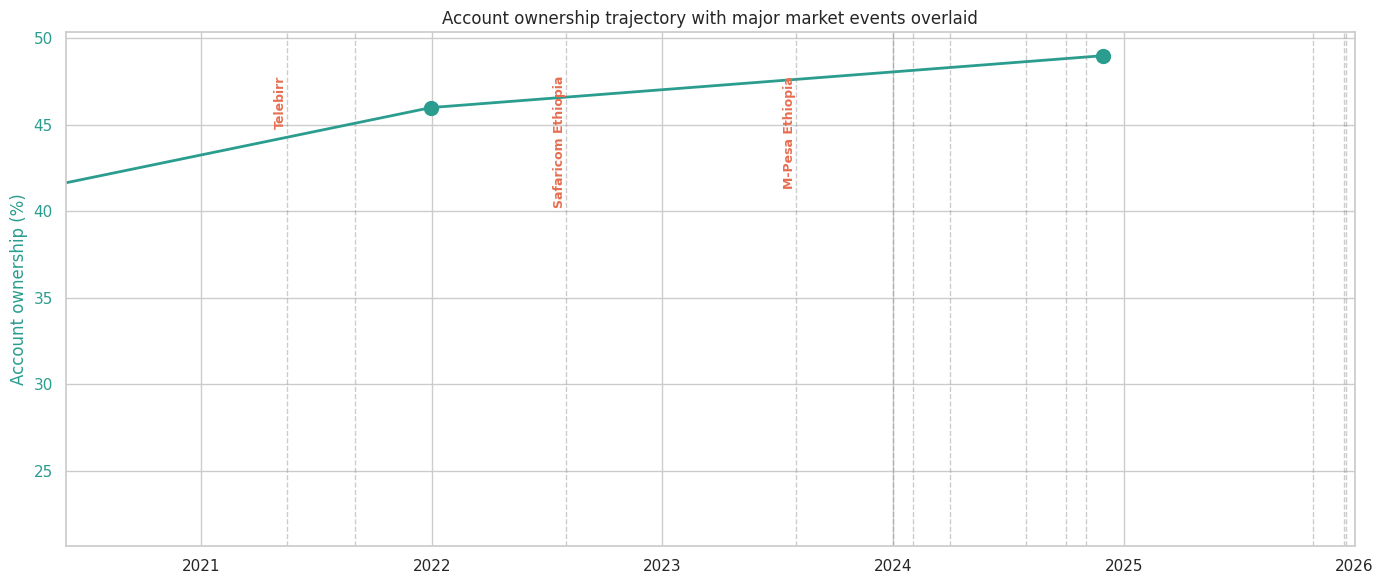

In [17]:
# Overlay events on the P2P transaction trend + account ownership trajectory
fig, ax1 = plt.subplots(figsize=(14, 6))

acc_all = obs[(obs['indicator_code'] == 'ACC_OWNERSHIP') & (obs['gender'] == 'all')].sort_values('observation_date')
ax1.plot(acc_all['observation_date'], acc_all['value_numeric'], marker='o', markersize=10,
         color='#2a9d8f', linewidth=2, label='Account ownership (%)')
ax1.set_ylabel('Account ownership (%)', color='#2a9d8f')
ax1.tick_params(axis='y', labelcolor='#2a9d8f')

for _, row in ev_sorted.iterrows():
    ax1.axvline(row['observation_date'], color='gray', linestyle='--', alpha=0.4, linewidth=1)

# Label the three headline product/market events specifically
highlight = ev_sorted[ev_sorted['record_id'].isin(['EVT_0001', 'EVT_0002', 'EVT_0003'])]
for _, row in highlight.iterrows():
    ax1.annotate(row['indicator'].replace(' Launch', '').replace(' Commercial', ''),
                 (row['observation_date'], ax1.get_ylim()[1] * 0.95),
                 rotation=90, va='top', ha='right', fontsize=9, color='#e76f51', fontweight='bold')

ax1.set_title('Account ownership trajectory with major market events overlaid')
ax1.set_xlim(pd.Timestamp('2020-06-01'), pd.Timestamp('2026-01-01'))
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/12_ownership_with_events.png')
plt.show()


**Visual read:** Telebirr (May 2021), Safaricom's entry (Aug 2022), and M-Pesa's launch
(Aug 2023) all sit *inside* the 2021-2024 window where Findex-measured account ownership grew only
+3pp. The events did drive massive mobile-money-specific activity (P2P transactions, registered
users) but that activity did not translate into materially higher Findex-measured Access. This is a
visual confirmation of the "registration vs. Findex ownership" gap discussed in Section 2.1 — the
events moved **Usage** far more than they moved headline **Access**.

## 6. Correlation Analysis

**Caveat:** with only 4-5 Findex observation points, formal Pearson correlation across the
full time series is not statistically meaningful (n is far too small for significance testing).
What follows is a directional/illustrative comparison of enabler indicators against the two
outcome pillars at their nearest available time points, not a rigorous statistical test.

In [18]:
# Build a simple year-aligned comparison table using the best-available (nearest) value per indicator per year
snapshot_indicators = ['ACC_OWNERSHIP', 'ACC_MM_ACCOUNT', 'ACC_4G_COV', 'ACC_MOBILE_PEN',
                        'ACC_SMARTPHONE_PEN', 'ENB_ELECTRICITY', 'USG_P2P_COUNT']
snap = obs[obs['indicator_code'].isin(snapshot_indicators) & (obs['gender'] == 'all')]
snap_pivot = snap.pivot_table(index='year', columns='indicator_code', values='value_numeric', aggfunc='mean')
snap_pivot


indicator_code,ACC_4G_COV,ACC_MM_ACCOUNT,ACC_MOBILE_PEN,ACC_OWNERSHIP,ACC_SMARTPHONE_PEN,ENB_ELECTRICITY,USG_P2P_COUNT
year,,,,,,,
2014,NaN,NaN,NaN,22.0,NaN,NaN,NaN
2017,NaN,NaN,NaN,35.0,NaN,NaN,NaN
2021,NaN,4.70,NaN,46.0,NaN,NaN,NaN
2023,37.5,NaN,NaN,NaN,NaN,NaN,NaN
2024,NaN,9.45,NaN,49.0,NaN,NaN,49700000.0
2025,70.8,NaN,61.4,NaN,15.0,54.0,128300000.0


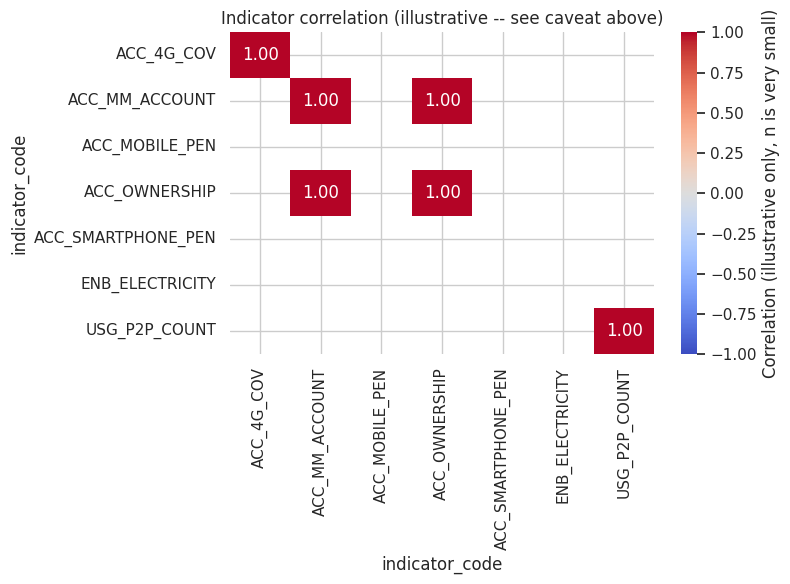

In [19]:
fig, ax = plt.subplots(figsize=(8, 6))
corr = snap_pivot.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-1, vmax=1, ax=ax,
            cbar_kws={'label': 'Correlation (illustrative only, n is very small)'})
ax.set_title('Indicator correlation (illustrative -- see caveat above)')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/13_correlation_heatmap.png')
plt.show()


Within this small-sample caveat: `ACC_MM_ACCOUNT`, `ACC_4G_COV`, and `USG_P2P_COUNT` all move
together strongly (as expected — they're all part of the same 2021-2025 mobile money boom), while
`ACC_OWNERSHIP` (the Findex headline) is comparatively flat and decoupled from them — the clearest
quantitative echo of the slowdown finding in Section 2.1. Existing `impact_link` records reinforce
this qualitatively: Telebirr's three modeled links all point to `USAGE`-side indicators
(`USG_TELEBIRR_USERS`, `USG_P2P_COUNT`), and only the newly-added NFIS-II link (`IMP_0019`, from
Task 1 enrichment) explicitly targets `ACC_OWNERSHIP` — the dataset's own event-impact modeling has,
until now, mostly bypassed the headline Access metric.

## 7. Key Insights

1. **Account ownership growth has stalled despite a mobile-money boom.** Growth dropped from
   +11pp (2017-2021) to +3pp (2021-2024), even as Telebirr, M-Pesa, and Safaricom all launched in
   that window. Mobile money account ownership (Findex-defined) did grow from 4.7% to 9.45%, but
   this is a *subset* of overall Access, not additive to it — most mobile money users already had a
   bank account (Market Nuances Sheet D: mobile-money-only users are ~0.5% of adults).

2. **Registered users vastly overstate real, Findex-comparable inclusion.** Telebirr reports ~55M
   registered users against a national adult population where Findex measures only 49% (roughly
   38-40M adults) holding any account at all. The registered-to-active gap is real and measurable:
   M-Pesa's 10.8M registered users convert to only 7.1M 90-day-active users (65.7%), consistent with
   NBE's sector-wide 66% mobile money activity rate.

3. **Device access, not network coverage, is now the binding constraint on Usage growth.** 4G
   population coverage (70.8%) and mobile subscription penetration (61.4%) are both far ahead of
   smartphone penetration (only 15%). As financial services shift toward QR/app-based payments
   (accelerated by the Apr-2024 ETHQR standard), this device gap could become the dominant bottleneck.

4. **Gender gaps are shifting in character, not just size.** The account-ownership gender gap
   narrowed modestly (20pp → 18pp, 2021-2024), but the smartphone-ownership gender gap (43pp, 2025)
   is now more than double that — meaning the frontier of gender inequality in financial inclusion is
   moving from *having an account* to *having the device needed to use newer digital services*.

5. **Events cluster around Usage-side indicators, leaving Access under-modeled.** Of the (now 19)
   impact_links in the dataset, the large majority target USAGE-pillar indicators (P2P counts,
   registered users, crossover ratios). Only one link (the Task-1-added `IMP_0019`, NFIS-II →
   `ACC_OWNERSHIP`) explicitly models a channel to the headline Access metric — a modeling gap that
   matters directly for Task 3/4, since our forecasting target is Access, and the event data mostly
   speaks to Usage.

6. **Real-time payment infrastructure (EthSwitch IPS, Feb 2024) shows the clearest before/after
   signal in the whole dataset.** P2P transaction counts roughly doubled in the 12 months after IPS
   launch and the P2P/ATM crossover ratio passed 1.0 by mid-2025 — the single cleanest event-to-
   outcome story available for Task 3 validation.


## 8. Data Quality Assessment

In [20]:
print("Confidence distribution across all observations:")
print(obs['confidence'].value_counts())
print(f"\n{(obs['confidence']=='high').mean()*100:.0f}% of observations are high-confidence.")

print("\nSource type distribution:")
print(obs['source_type'].value_counts())


Confidence distribution across all observations:
confidence
high      32
medium    10
Name: count, dtype: int64

76% of observations are high-confidence.

Source type distribution:
source_type
research      16
operator      11
survey        10
regulator      3
calculated     2
Name: count, dtype: int64


**Limitations documented:**

- **Sparse core time series.** Only 4-5 Findex survey points exist for the actual target variables
  (Access, Usage) across 13 years — everything else is annual-or-less operator/infrastructure data
  layered around those few anchor points. Any regression-based forecast (Task 4) will have very
  limited degrees of freedom.
- **No urban/rural or regional disaggregation exists** in either the base or enriched dataset,
  despite the challenge brief asking us to investigate it if available. This is a genuine gap, not
  an oversight — it should be flagged to the consortium as a priority for the next data-collection
  round rather than approximated here.
- **Literacy rate has conflicting secondary sources** (71.04% vs. 60.5% for the same year, 2022) —
  flagged at `medium` confidence in Task 1 rather than silently resolved.
- **Self-reported operator metrics** (e.g., EthSwitch's 47% IPS cost-reduction claim) are marked
  `medium`, not `high`, confidence, since they aren't independently audited.
- **Correlation analysis is illustrative only** — the n is far too small (4-7 data points per
  indicator) for any claim of statistical significance; relationships shown should be read as
  "consistent with a plausible mechanism," not "proven."
- **`ACC_OWNERSHIP` overall figure for 2024 (49%) has no gender-disaggregated pair** — REC_0004/0005
  (male/female) exist for 2021 but not 2024, since GEN_GAP_ACC (18pp, 2024) is reported as a gap
  without the underlying male/female values. Growth-rate-by-gender for the most recent period can't
  be directly computed from the current data.


## Summary

- Confirmed a genuine slowdown in Findex-measured account ownership growth (+11pp → +3pp) that
  coincides with, rather than being explained away by, Ethiopia's mobile money boom.
- Identified the "registered vs. Findex-active" gap as the central mechanism behind that apparent
  paradox, cross-validated across two independent sources (M-Pesa's own numbers and NBE's sector-
  wide activity rate).
- Found that gender inequality is shifting from account access toward *device* access.
- Confirmed visually and via the impact_link data that most modeled event effects target Usage, not
  Access — directly relevant to how Task 3/4 should be scoped.
- Documented real, material data-quality limitations (sparsity, missing disaggregation, source
  conflicts) rather than papering over them.

**Next:** Task 3 — Event Impact Modeling, building the event-indicator association matrix and
validating it against the historical patterns found here (especially the EthSwitch IPS effect).
